In [118]:
!uv pip install numpy pandas matplotlib nltk pythainlp scikit-learn

Using Python 3.11.15 environment at: /home/kami/Projects/NLP/.venv
Checked 6 packages in 1ms


In [119]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /home/kami/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/kami/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/kami/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [120]:
train = pd.read_csv('./financial-news-data/financial-news-train.csv', encoding='utf-8')
test = pd.read_csv('./financial-news-data/financial-news-test.csv', encoding='utf-8')

In [121]:
def clean_text_dataframe(df, drop_duplicates=True):
    # Lowercase
    df['text'] = df['text'].str.lower()

    # Remove quotes
    df['text'] = df['text'].str.replace('"', '', regex=False)

    # Remove links
    df['text'] = df['text'].str.replace(r'https?://\S+', '', regex=True)

    # Remove words that don't start with an alphabetic character
    df['text'] = df['text'].str.replace(r'\b[^a-z\s]\S*', '', regex=True)

    # Remove non-alphabetic characters
    df['text'] = df['text'].str.replace(r'[^a-z\s]', '', regex=True)

    # Normalize whitespace after removals
    df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

    if drop_duplicates:
        df.drop_duplicates(subset=['text'], inplace=True)

    # NLTK remove stopwods
    stop_words = set(stopwords.words('english'))
    df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

In [122]:
# Show full text
pd.set_option('display.max_colwidth', None)

clean_text_dataframe(train)
clean_text_dataframe(test, drop_duplicates=False)

train

,text,label
0,thursday biggest analyst calls apple amazon tesla palantir docusign exxon amp,Analyst Update
1,buy las vegas sands travel singapore builds wells fargo says,Analyst Update
2,piper sandler downgrades docusign sell citing elevated risks amid ceo transition,Analyst Update
3,analysts react tesla latest earnings break next electric car maker,Analyst Update
4,netflix peers set return growth analysts say giving one stock upside,Analyst Update
...,...,...
16984,china developers face wall dollar bond payments second half,Treasuries | Corporate Debt
16985,kfw credit line uniper could raised bln eur handelsblatt,Treasuries | Corporate Debt
16987,russian sells bln roubles one repo auction,Treasuries | Corporate Debt
16988,global esg bond issuance posts h dip supranationals cut back,Treasuries | Corporate Debt


In [123]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train = vectorizer.fit_transform(train['text'])
X_test = vectorizer.transform(test['text'])

In [ ]:
vectorizer.get_feature_names_out()

False

In [116]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train = encoder.fit_transform(train['label'])
y_test = encoder.transform(test['label'])

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, fit_intercept=True)
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [79]:
pred = model.predict(X_test)

In [101]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

#Q1

print("Classification Report:")
print(classification_report(
    y_test,
    pred,
    target_names=encoder.classes_,
    digits=3,
    zero_division=0
))

Classification Report:
                             precision    recall  f1-score   support

             Analyst Update      0.926     0.685     0.787        73
     Company | Product News      0.804     0.888     0.844       852
                 Currencies      0.917     0.688     0.786        32
                   Dividend      0.980     0.990     0.985        97
                   Earnings      0.958     0.938     0.948       242
               Energy | Oil      0.844     0.781     0.811       146
        Fed | Central Banks      0.863     0.827     0.845       214
                 Financials      0.890     0.863     0.876       160
     General News | Opinion      0.752     0.777     0.764       336
  Gold | Metals | Materials      0.438     0.538     0.483        13
                        IPO      1.000     0.429     0.600        14
         Legal | Regulation      0.879     0.731     0.798       119
          M&A | Investments      0.839     0.672     0.746       116
          

In [80]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

#Q1

print("Classification Report:")
print(classification_report(
    y_test,
    pred,
    target_names=encoder.classes_,
    digits=3,
    zero_division=0
))

Classification Report:
                             precision    recall  f1-score   support

             Analyst Update      0.926     0.685     0.787        73
     Company | Product News      0.804     0.888     0.844       852
                 Currencies      0.917     0.688     0.786        32
                   Dividend      0.980     0.990     0.985        97
                   Earnings      0.958     0.938     0.948       242
               Energy | Oil      0.844     0.781     0.811       146
        Fed | Central Banks      0.863     0.827     0.845       214
                 Financials      0.890     0.863     0.876       160
     General News | Opinion      0.752     0.777     0.764       336
  Gold | Metals | Materials      0.438     0.538     0.483        13
                        IPO      1.000     0.429     0.600        14
         Legal | Regulation      0.879     0.731     0.798       119
          M&A | Investments      0.839     0.672     0.746       116
          

In [81]:
model_weights = pd.DataFrame(model.coef_, columns=vectorizer.get_feature_names_out(), index=encoder.classes_).T
model_weights

,Analyst Update,Company | Product News,Currencies,Dividend,Earnings,Energy | Oil,Fed | Central Banks,Financials,General News | Opinion,Gold | Metals | Materials,IPO,Legal | Regulation,M&A | Investments,Macro,Markets,Personnel Change,Politics,Stock Commentary,Stock Movement,Treasuries | Corporate Debt
aa,0.427423,-0.058609,-0.027103,-0.016255,-0.151233,-0.046345,-0.042873,0.042961,-0.045695,-0.031748,-0.015606,-0.027837,-0.024753,-0.211608,-0.051048,-0.027928,-0.035486,0.351458,0.031425,-0.039140
aad,-0.000109,0.035357,-0.000209,-0.000030,-0.000031,-0.000183,-0.000709,-0.000114,-0.023413,-0.000034,-0.000068,-0.003314,-0.000964,-0.000371,-0.000138,-0.004057,-0.000886,-0.000243,-0.000183,-0.000302
aaic,-0.000709,-0.026158,-0.003187,-0.000087,-0.000230,-0.003496,-0.002450,-0.000312,-0.003257,-0.001348,-0.000792,-0.000446,-0.000323,-0.000767,-0.014466,-0.001681,-0.001491,0.082305,-0.019951,-0.001152
aaii,-0.000253,-0.003035,-0.001806,-0.000375,-0.003836,-0.000693,-0.001296,-0.000442,-0.000466,-0.000499,-0.000299,-0.000312,-0.002250,0.100449,-0.000310,-0.000871,-0.000598,-0.081876,-0.000350,-0.000882
aal,-0.119158,0.304647,-0.051453,-0.016359,0.194433,-0.263507,-0.076226,0.095803,-0.203735,-0.038441,-0.025682,-0.055601,-0.077870,-0.200360,-0.099952,-0.073008,-0.063888,0.668011,0.150922,-0.048572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zynerba,-0.000074,-0.018837,-0.000056,-0.000055,-0.000056,-0.000151,-0.000217,-0.000084,-0.002821,-0.000050,-0.000051,-0.002133,-0.010068,-0.000179,-0.000223,-0.000064,-0.000158,-0.000301,0.035843,-0.000264
zynlonta,-0.000037,0.001330,-0.000037,-0.000036,-0.000037,-0.000041,-0.000058,-0.000159,-0.000093,-0.000036,-0.000037,-0.000062,-0.000076,-0.000158,-0.000042,-0.000061,-0.000078,-0.000054,-0.000168,-0.000060
zynx,-0.003435,0.208823,-0.001917,-0.005158,-0.003677,-0.001882,-0.001475,-0.006632,-0.037687,-0.002659,-0.003372,-0.007233,-0.048274,-0.029543,-0.001959,-0.008851,-0.004218,-0.030244,-0.005471,-0.005136
zyus,-0.005338,0.322919,-0.003212,-0.023348,-0.002136,-0.102549,-0.009348,-0.007444,-0.036611,-0.004209,-0.005113,-0.014333,-0.033267,-0.024623,-0.005453,-0.005486,-0.005604,-0.009259,-0.009716,-0.015870


In [82]:
model_weights.to_csv('model_weights.csv', index=True)

In [83]:
#Q2

best_weights = []
worst_weights = []

# Get 2 best performing labels based on F1 score
f1_scores = f1_score(y_test, pred, average=None)
best_labels = f1_scores.argsort()[::-1][:2]
best_labels_name = encoder.inverse_transform(best_labels)

print(best_labels_name)

['Dividend' 'Earnings']


In [84]:
for label in best_labels_name:
    print(f"\nTop 10 features for label '{label}':")
    top_features = model_weights[label].sort_values(ascending=False).head(10)
    print(top_features)
    best_weights.append(top_features.tolist())


Top 10 features for label 'Dividend':
dividend         5.065448
distribution     2.640214
declares         2.399156
distributions    1.407148
quarterly        1.306912
dividends        1.238528
announces        1.229556
trust            1.167393
ex               1.080978
july             0.975300
Name: Dividend, dtype: float64

Top 10 features for label 'Earnings':
earnings      5.272072
results       3.776076
quarter       1.752832
preview       1.686428
call          1.656281
reports       1.305984
conference    1.271961
august        1.191061
second        1.143226
profit        1.141659
Name: Earnings, dtype: float64


In [85]:
# Q3

# Get 2 worst performing labels based on F1 score
worst_labels = f1_scores.argsort()[::-1][-2:]
worst_labels_name = encoder.inverse_transform(worst_labels)

print(worst_labels_name)

for label in worst_labels_name:
    print(f"\nTop 10 features for label '{label}':")
    top_features = model_weights[label].sort_values(ascending=False).head(10)
    print(top_features)
    worst_weights.append(top_features.tolist())

['IPO' 'Gold | Metals | Materials']

Top 10 features for label 'IPO':
ipo        4.359059
ipos       1.425608
public     1.259169
go         1.016619
spac       0.885063
hong       0.754651
kong       0.754651
dubai      0.731392
porsche    0.680522
listing    0.640323
Name: IPO, dtype: float64

Top 10 features for label 'Gold | Metals | Materials':
gold         3.884345
copper       1.825656
metals       1.600364
dollar       1.221574
gld          0.878170
investors    0.847259
base         0.799787
nickel       0.754166
years        0.742428
drops        0.712092
Name: Gold | Metals | Materials, dtype: float64


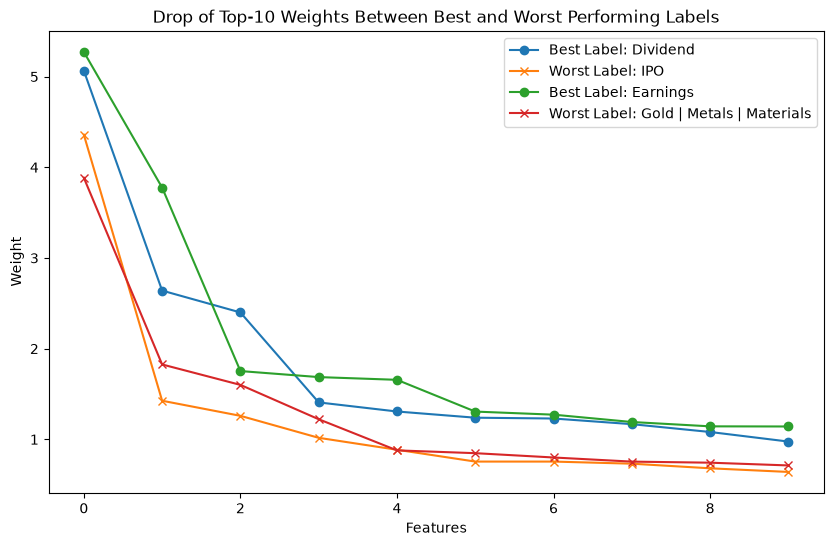

In [86]:
import matplotlib.pyplot as plt

# plot the drop of the top-10 weight between the best and worst performing labels
plt.figure(figsize=(10, 6))
plt.xlabel('Features')
plt.ylabel('Weight')
plt.title('Drop of Top-10 Weights Between Best and Worst Performing Labels')

# Plot
for i in range(2):
    plt.plot(range(10), best_weights[i], marker='o', label=f'Best Label: {best_labels_name[i]}')
    plt.plot(range(10), worst_weights[i], marker='x', label=f'Worst Label: {worst_labels_name[i]}')

# Legend
plt.legend()

plt.show()

In [87]:
# Check frequency of the word 'prices' in the training data grouped by each label
train['prices_count'] = train['text'].apply(lambda x: x.split().count('earnings'))
prices_count_by_label = train.groupby('label')['prices_count'].sum()
prices_count_by_label

label
Analyst Update                  22
Company | Product News           4
Currencies                       1
Dividend                         0
Earnings                       651
Energy | Oil                     0
Fed | Central Banks              2
Financials                      64
General News | Opinion           5
Gold | Metals | Materials        0
IPO                              0
Legal | Regulation               0
M&A | Investments                2
Macro                           11
Markets                         80
Personnel Change                 0
Politics                         0
Stock Commentary                19
Stock Movement                  91
Treasuries | Corporate Debt      3
Name: prices_count, dtype: int64

In [88]:
# Count the label in the training data
train['label'].value_counts()

label
Company | Product News         3287
Stock Commentary               1987
Macro                          1455
General News | Opinion         1239
Earnings                        974
Politics                        864
Stock Movement                  800
Fed | Central Banks             686
Financials                      598
Personnel Change                478
M&A | Investments               455
Legal | Regulation              448
Energy | Oil                    445
Markets                         436
Dividend                        359
Analyst Update                  246
Treasuries | Corporate Debt     243
Currencies                      141
Gold | Metals | Materials        58
IPO                              42
Name: count, dtype: int64

In [89]:
model.intercept_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])